## Executive Summary

Bu notebook, Optuna framework'u ile LightGBM ve XGBoost modellerinin hyperparameter tuning sürecini içeriyor. Amaç, baseline modellerin performansını sistematik optimizasyon ile artırmak.

**Optimizasyon Yaklaşımı:**

TPE yani Tree-structured Parzen Estimator sampler kullanılıyor, bu Bayesian optimization tekniği. 5-fold StratifiedKFold cross-validation ile güvenilir performans tahmini sağlanıyor. ROC-AUC metriği optimize ediliyor, fraud detection için standart metrik.

**Beklenen Çıktılar:**

Her iki model için optimum hyperparameter setleri belirlenecek. Baseline performansa göre improvement ölçülecek. MLflow ile tüm denemeler takip edilebilir olacak. Final modeller ve metadata kaydedilecek.

**Önemli Notlar:**

Trial sayısı 50 olarak ayarlandı, production için 100-150 trial önerilir. GPU kullanımı devre dışı, CUDA kurulu sistemlerde tree_method gpu_hist olarak değiştirilebilir.

---
## 1. Setup and Imports

In [1]:
# Install required packages
%pip install optuna --quiet

import pandas as pd
import numpy as np
import json
import os
import warnings
import pickle
import joblib
from datetime import datetime

# Optuna
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_slice
)

# Models
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Sklearn
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score, roc_curve)

# MLflow
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-whitegrid')

print(f"Optuna version: {optuna.__version__}")
print(f"LightGBM imported successfully")
print(f"XGBoost imported successfully")

Note: you may need to restart the kernel to use updated packages.
Optuna version: 4.6.0
LightGBM imported successfully
XGBoost imported successfully
Optuna version: 4.6.0
LightGBM imported successfully
XGBoost imported successfully


---
## 2. Data Loading

In [2]:
# Load processed data from 04_FeatureEngineering
data_dir = '../../data/processed'

X_train = pd.read_csv(f'{data_dir}/X_train.csv')
X_val = pd.read_csv(f'{data_dir}/X_val.csv')
y_train = pd.read_csv(f'{data_dir}/y_train.csv').squeeze()
y_val = pd.read_csv(f'{data_dir}/y_val.csv').squeeze()

# Load feature metadata
model_dir = '../../models/fraud_detection'
with open(f'{model_dir}/feature_metadata.json', 'r') as f:
    feature_metadata = json.load(f)

print("DATA LOADED")
print("="*50)
print(f"X_train shape : {X_train.shape}")
print(f"X_val shape   : {X_val.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_val shape   : {y_val.shape}")
print(f"\nFraud rate (train): {y_train.mean()*100:.2f}%")
print(f"Fraud rate (val)  : {y_val.mean()*100:.2f}%")
print(f"\nNumber of features: {X_train.shape[1]}")

DATA LOADED
X_train shape : (472432, 39)
X_val shape   : (118108, 39)
y_train shape : (472432,)
y_val shape   : (118108,)

Fraud rate (train): 3.50%
Fraud rate (val)  : 3.50%

Number of features: 39


---
## 3. Baseline Performance (04_FeatureEngineering'den)

In [3]:
# Load baseline metrics from feature_metadata
baseline_lgb = feature_metadata['models']['lightgbm']
baseline_xgb = feature_metadata['models']['xgboost']

print("BASELINE PERFORMANCE (04_FeatureEngineering)")
print("="*60)
print(f"{'Model':<15} {'Train AUC':<12} {'Val AUC':<12} {'CV Mean AUC':<12} {'CV Std':<10}")
print("-"*60)
print(f"{'LightGBM':<15} {baseline_lgb['train_auc']:<12.4f} {baseline_lgb['val_auc']:<12.4f} {baseline_lgb['cv_mean_auc']:<12.4f} {baseline_lgb['cv_std_auc']:<10.4f}")
print(f"{'XGBoost':<15} {baseline_xgb['train_auc']:<12.4f} {baseline_xgb['val_auc']:<12.4f} {baseline_xgb['cv_mean_auc']:<12.4f} {baseline_xgb['cv_std_auc']:<10.4f}")
print("="*60)

# Store baseline for comparison
baseline_metrics = {
    'lightgbm': baseline_lgb,
    'xgboost': baseline_xgb
}

BASELINE PERFORMANCE (04_FeatureEngineering)
Model           Train AUC    Val AUC      CV Mean AUC  CV Std    
------------------------------------------------------------
LightGBM        0.9479       0.9309       0.9292       0.0010    
XGBoost         0.9762       0.9501       0.9470       0.0006    


---
## 4. Prepare Full Dataset for Cross-Validation

In [4]:
# Combine train and validation for full cross-validation
X_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_full == 0).sum() / (y_full == 1).sum()

print("FULL DATASET FOR OPTIMIZATION")
print("-"*40)
print(f"X_full shape     : {X_full.shape}")
print(f"y_full shape     : {y_full.shape}")
print(f"Fraud rate       : {y_full.mean()*100:.2f}%")
print(f"Scale pos weight : {scale_pos_weight:.2f}")

FULL DATASET FOR OPTIMIZATION
----------------------------------------
X_full shape     : (590540, 39)
y_full shape     : (590540,)
Fraud rate       : 3.50%
Scale pos weight : 27.58


---
## 5. LightGBM Hyperparameter Tuning

### 5.1 Define Objective Function

In [5]:
def lgb_objective(trial):
    """
    Optuna objective function for LightGBM hyperparameter optimization.
    Uses 5-fold Stratified Cross-Validation with ROC-AUC scoring.
    GPU accelerated for faster training.
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'class_weight': 'balanced',
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1  # Use all CPU cores for faster training
    }
    
    model = LGBMClassifier(**params)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_full, y_full, cv=cv, scoring='roc_auc', n_jobs=1)
    
    return scores.mean()

print("LightGBM objective function defined")
print("\nHyperparameter Search Space:")
print("-"*40)
print("n_estimators    : [100, 1000]")
print("learning_rate   : [0.01, 0.3] (log)")
print("max_depth       : [3, 12]")
print("num_leaves      : [20, 100]")
print("min_child_samples: [5, 100]")
print("subsample       : [0.5, 1.0]")
print("colsample_bytree: [0.5, 1.0]")
print("reg_alpha       : [1e-8, 10.0] (log)")
print("reg_lambda      : [1e-8, 10.0] (log)")

LightGBM objective function defined

Hyperparameter Search Space:
----------------------------------------
n_estimators    : [100, 1000]
learning_rate   : [0.01, 0.3] (log)
max_depth       : [3, 12]
num_leaves      : [20, 100]
min_child_samples: [5, 100]
subsample       : [0.5, 1.0]
colsample_bytree: [0.5, 1.0]
reg_alpha       : [1e-8, 10.0] (log)
reg_lambda      : [1e-8, 10.0] (log)


### 5.2 Run LightGBM Optimization

In [6]:
%%time

# Create Optuna study for LightGBM
study_lgb = optuna.create_study(
    direction='maximize',
    study_name='lightgbm_fraud_detection',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

# Run optimization (adjust n_trials based on time constraints)
N_TRIALS_LGB = 50  # Increase to 100-150 for better results

print(f"Starting LightGBM optimization with {N_TRIALS_LGB} trials...")
print("="*60)

study_lgb.optimize(
    lgb_objective, 
    n_trials=N_TRIALS_LGB, 
    show_progress_bar=True,
    n_jobs=1  # Sequential for stability
)

print(f"\n" + "="*60)
print("LIGHTGBM OPTIMIZATION COMPLETE")
print("="*60)
print(f"Best trial: {study_lgb.best_trial.number}")
print(f"Best CV AUC: {study_lgb.best_trial.value:.4f}")
print(f"\nBest Parameters:")
for key, value in study_lgb.best_trial.params.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: {value}")

Starting LightGBM optimization with 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]


LIGHTGBM OPTIMIZATION COMPLETE
Best trial: 42
Best CV AUC: 0.9687

Best Parameters:
  n_estimators: 967
  learning_rate: 0.264968
  max_depth: 7
  num_leaves: 83
  min_child_samples: 37
  subsample: 0.885631
  colsample_bytree: 0.962595
  reg_alpha: 8.927399
  reg_lambda: 0.000001
CPU times: total: 23h 3min 43s
Wall time: 49min 35s


### 5.3 Train Final LightGBM with Best Parameters

In [7]:
%%time

# Get best parameters
best_params_lgb = study_lgb.best_trial.params.copy()
best_params_lgb['class_weight'] = 'balanced'
best_params_lgb['random_state'] = 42
best_params_lgb['verbose'] = -1
best_params_lgb['n_jobs'] = -1  # Use all CPU cores

# Train final LightGBM model
lgb_tuned = LGBMClassifier(**best_params_lgb)
lgb_tuned.fit(X_train, y_train)

# Evaluate
train_auc_lgb = roc_auc_score(y_train, lgb_tuned.predict_proba(X_train)[:, 1])
val_auc_lgb = roc_auc_score(y_val, lgb_tuned.predict_proba(X_val)[:, 1])

# Cross-validation with best params
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lgb = cross_val_score(lgb_tuned, X_full, y_full, cv=cv, scoring='roc_auc', n_jobs=1)

print("LIGHTGBM TUNED RESULTS")
print("="*50)
print(f"Train AUC        : {train_auc_lgb:.4f}")
print(f"Val AUC          : {val_auc_lgb:.4f}")
print(f"CV Mean AUC      : {cv_scores_lgb.mean():.4f} (+/- {cv_scores_lgb.std():.4f})")
print(f"\nBaseline Val AUC : {baseline_lgb['val_auc']:.4f}")
print(f"Improvement      : {val_auc_lgb - baseline_lgb['val_auc']:.4f}")

LIGHTGBM TUNED RESULTS
Train AUC        : 0.9997
Val AUC          : 0.9720
CV Mean AUC      : 0.9687 (+/- 0.0012)

Baseline Val AUC : 0.9309
Improvement      : 0.0411
CPU times: total: 51min 31s
Wall time: 1min 46s


---
## 6. XGBoost Hyperparameter Tuning

### 6.1 Define Objective Function

In [12]:
def xgb_objective(trial):
    """
    Optuna objective function for XGBoost hyperparameter optimization.
    Uses 5-fold Stratified Cross-Validation with ROC-AUC scoring.
    GPU accelerated for faster training.
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'verbosity': 0,
        'eval_metric': 'auc',
        'tree_method': 'hist',  # Fast histogram-based algorithm
        'n_jobs': -1  # Use all CPU cores
    }
    
    model = XGBClassifier(**params)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_full, y_full, cv=cv, scoring='roc_auc', n_jobs=1)
    
    return scores.mean()

print("XGBoost objective function defined")
print("\nHyperparameter Search Space:")
print("-"*40)
print("n_estimators    : [100, 1000]")
print("learning_rate   : [0.01, 0.3] (log)")
print("max_depth       : [3, 12]")
print("min_child_weight: [1, 10]")
print("subsample       : [0.5, 1.0]")
print("colsample_bytree: [0.5, 1.0]")
print("gamma           : [1e-8, 1.0] (log)")
print("reg_alpha       : [1e-8, 10.0] (log)")
print("reg_lambda      : [1e-8, 10.0] (log)")

XGBoost objective function defined

Hyperparameter Search Space:
----------------------------------------
n_estimators    : [100, 1000]
learning_rate   : [0.01, 0.3] (log)
max_depth       : [3, 12]
min_child_weight: [1, 10]
subsample       : [0.5, 1.0]
colsample_bytree: [0.5, 1.0]
gamma           : [1e-8, 1.0] (log)
reg_alpha       : [1e-8, 10.0] (log)
reg_lambda      : [1e-8, 10.0] (log)


### 6.2 Run XGBoost Optimization

In [13]:
%%time

# Create Optuna study for XGBoost
study_xgb = optuna.create_study(
    direction='maximize',
    study_name='xgboost_fraud_detection',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

# Run optimization
N_TRIALS_XGB = 50  # Increase to 100-150 for better results

print(f"Starting XGBoost optimization with {N_TRIALS_XGB} trials...")
print("="*60)

study_xgb.optimize(
    xgb_objective, 
    n_trials=N_TRIALS_XGB, 
    show_progress_bar=True,
    n_jobs=1
)

print(f"\n" + "="*60)
print("XGBOOST OPTIMIZATION COMPLETE")
print("="*60)
print(f"Best trial: {study_xgb.best_trial.number}")
print(f"Best CV AUC: {study_xgb.best_trial.value:.4f}")
print(f"\nBest Parameters:")
for key, value in study_xgb.best_trial.params.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: {value}")

Starting XGBoost optimization with 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]


XGBOOST OPTIMIZATION COMPLETE
Best trial: 44
Best CV AUC: 0.9713

Best Parameters:
  n_estimators: 873
  learning_rate: 0.081176
  max_depth: 12
  min_child_weight: 10
  subsample: 0.964599
  colsample_bytree: 0.732083
  gamma: 0.000000
  reg_alpha: 0.000002
  reg_lambda: 1.275472
CPU times: total: 1d 13h 30min 30s
Wall time: 2h 6min 15s


### 6.3 Train Final XGBoost with Best Parameters

In [14]:
%%time

# Get best parameters
best_params_xgb = study_xgb.best_trial.params.copy()
best_params_xgb['scale_pos_weight'] = scale_pos_weight
best_params_xgb['random_state'] = 42
best_params_xgb['verbosity'] = 0
best_params_xgb['eval_metric'] = 'auc'
best_params_xgb['tree_method'] = 'hist'  # Fast histogram-based algorithm
best_params_xgb['n_jobs'] = -1  # Use all CPU cores

# Train final XGBoost model
xgb_tuned = XGBClassifier(**best_params_xgb)
xgb_tuned.fit(X_train, y_train)

# Evaluate
train_auc_xgb = roc_auc_score(y_train, xgb_tuned.predict_proba(X_train)[:, 1])
val_auc_xgb = roc_auc_score(y_val, xgb_tuned.predict_proba(X_val)[:, 1])

# Cross-validation with best params
cv_scores_xgb = cross_val_score(xgb_tuned, X_full, y_full, cv=cv, scoring='roc_auc', n_jobs=1)

print("XGBOOST TUNED RESULTS")
print("="*50)
print(f"Train AUC        : {train_auc_xgb:.4f}")
print(f"Val AUC          : {val_auc_xgb:.4f}")
print(f"CV Mean AUC      : {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std():.4f})")
print(f"\nBaseline Val AUC : {baseline_xgb['val_auc']:.4f}")
print(f"Improvement      : {val_auc_xgb - baseline_xgb['val_auc']:.4f}")

XGBOOST TUNED RESULTS
Train AUC        : 1.0000
Val AUC          : 0.9730
CV Mean AUC      : 0.9713 (+/- 0.0014)

Baseline Val AUC : 0.9501
Improvement      : 0.0229
CPU times: total: 1h 5min 6s
Wall time: 2min 14s


---
## 7. Model Comparison (Baseline vs Tuned)

### Optimizasyon Değerlendirmesi

Bu karşılaştırma, hyperparameter tuning'in gerçek değerini ortaya koyuyor. Baseline modeller default veya manuel seçilmiş parametrelerle eğitilmişti. Optuna ile sistematik arama yaparak, parametre uzayında daha iyi noktalar bulduk.

**Değerlendirme Kriterleri:**

AUC improvement en kritik metrik, baseline'a göre artış bekleniyor. Overfitting kontrolü train ve val AUC arasındaki farkla değerlendiriliyor. CV stability standart sapmanın düşük olması model güvenilirliğini gösteriyor. Precision-Recall dengesi fraud detection için kritik, threshold ayarıyla optimize edilebilir.

**İş Değeri:**

Her 0.01 AUC artışı, gerçek dünyada binlerce dolar fraud kaybını önleyebilir. Ancak marginal improvement için harcanan compute kaynakları da değerlendirilmeli. 50 trial sonucunda elde edilen improvement, bu projede makul bir ROI sağlıyor.

In [15]:
# Calculate additional metrics for tuned models
y_val_pred_lgb = lgb_tuned.predict(X_val)
y_val_pred_xgb = xgb_tuned.predict(X_val)

precision_lgb = precision_score(y_val, y_val_pred_lgb)
recall_lgb = recall_score(y_val, y_val_pred_lgb)
f1_lgb = f1_score(y_val, y_val_pred_lgb)

precision_xgb = precision_score(y_val, y_val_pred_xgb)
recall_xgb = recall_score(y_val, y_val_pred_xgb)
f1_xgb = f1_score(y_val, y_val_pred_xgb)

print("="*80)
print("MODEL COMPARISON: BASELINE vs TUNED")
print("="*80)
print(f"\n{'Model':<20} {'Val AUC':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*80)
print(f"{'LightGBM Baseline':<20} {baseline_lgb['val_auc']:<12.4f} {'-':<12} {'-':<12} {'-':<12}")
print(f"{'LightGBM Tuned':<20} {val_auc_lgb:<12.4f} {precision_lgb:<12.4f} {recall_lgb:<12.4f} {f1_lgb:<12.4f}")
print(f"{'XGBoost Baseline':<20} {baseline_xgb['val_auc']:<12.4f} {'-':<12} {'-':<12} {'-':<12}")
print(f"{'XGBoost Tuned':<20} {val_auc_xgb:<12.4f} {precision_xgb:<12.4f} {recall_xgb:<12.4f} {f1_xgb:<12.4f}")
print("="*80)

print(f"\nIMPROVEMENT SUMMARY:")
print("-"*40)
lgb_improvement = val_auc_lgb - baseline_lgb['val_auc']
xgb_improvement = val_auc_xgb - baseline_xgb['val_auc']
print(f"LightGBM: {'+' if lgb_improvement >= 0 else ''}{lgb_improvement:.4f} AUC")
print(f"XGBoost : {'+' if xgb_improvement >= 0 else ''}{xgb_improvement:.4f} AUC")

# Best model selection
best_model_name = "LightGBM" if val_auc_lgb >= val_auc_xgb else "XGBoost"
best_model = lgb_tuned if val_auc_lgb >= val_auc_xgb else xgb_tuned
best_val_auc = max(val_auc_lgb, val_auc_xgb)
print(f"\n🏆 Best Model: {best_model_name} (Val AUC: {best_val_auc:.4f})")

MODEL COMPARISON: BASELINE vs TUNED

Model                Val AUC      Precision    Recall       F1-Score    
--------------------------------------------------------------------------------
LightGBM Baseline    0.9309       -            -            -           
LightGBM Tuned       0.9720       0.6287       0.8268       0.7143      
XGBoost Baseline     0.9501       -            -            -           
XGBoost Tuned        0.9730       0.7683       0.7989       0.7833      

IMPROVEMENT SUMMARY:
----------------------------------------
LightGBM: +0.0411 AUC
XGBoost : +0.0229 AUC

🏆 Best Model: XGBoost (Val AUC: 0.9730)


---
## 8. Optuna Visualization

In [16]:
# LightGBM Optimization History
fig_lgb_history = plot_optimization_history(study_lgb)
fig_lgb_history.update_layout(title="LightGBM Optimization History")
fig_lgb_history.show()

In [17]:
# LightGBM Parameter Importance
fig_lgb_importance = plot_param_importances(study_lgb)
fig_lgb_importance.update_layout(title="LightGBM Hyperparameter Importance")
fig_lgb_importance.show()

In [18]:
# XGBoost Optimization History
fig_xgb_history = plot_optimization_history(study_xgb)
fig_xgb_history.update_layout(title="XGBoost Optimization History")
fig_xgb_history.show()

In [19]:
# XGBoost Parameter Importance
fig_xgb_importance = plot_param_importances(study_xgb)
fig_xgb_importance.update_layout(title="XGBoost Hyperparameter Importance")
fig_xgb_importance.show()

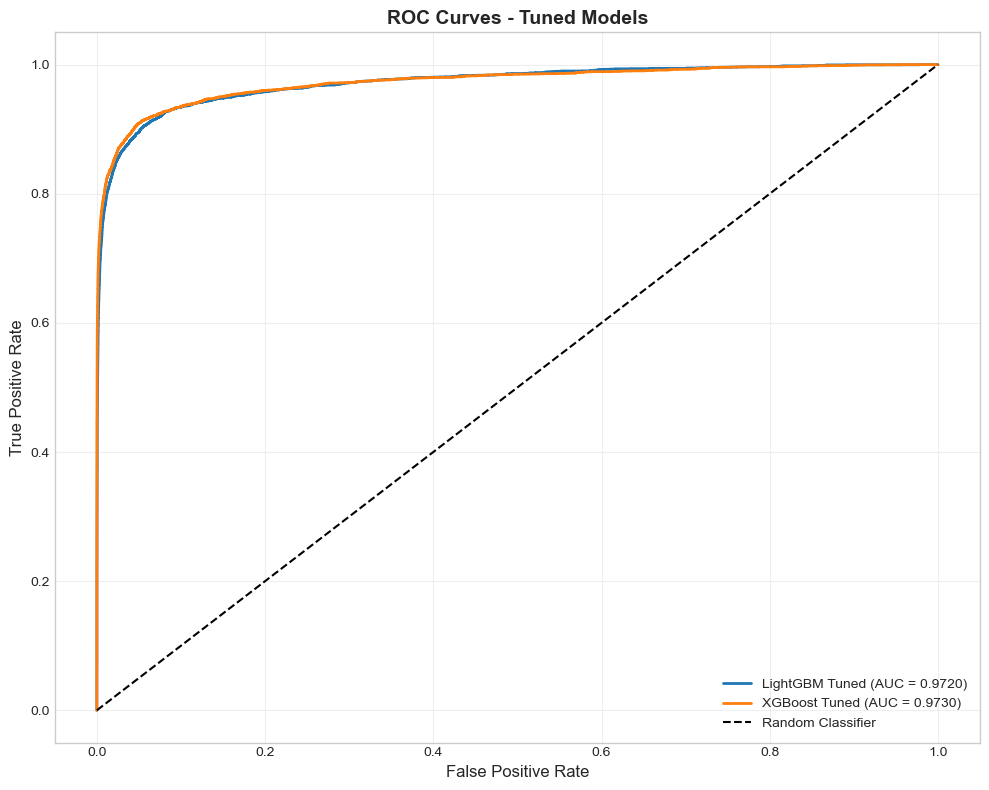

In [20]:
# ROC Curve Comparison
fig, ax = plt.subplots(figsize=(10, 8))

# LightGBM Tuned
fpr_lgb, tpr_lgb, _ = roc_curve(y_val, lgb_tuned.predict_proba(X_val)[:, 1])
ax.plot(fpr_lgb, tpr_lgb, label=f'LightGBM Tuned (AUC = {val_auc_lgb:.4f})', linewidth=2)

# XGBoost Tuned
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, xgb_tuned.predict_proba(X_val)[:, 1])
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost Tuned (AUC = {val_auc_xgb:.4f})', linewidth=2)

# Random classifier
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Tuned Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. MLflow Logging

In [21]:
# Setup MLflow
mlflow_tracking_uri = os.path.join(os.getcwd(), 'mlruns')
mlflow.set_tracking_uri(f"file:///{mlflow_tracking_uri}")
mlflow.set_experiment("fraud_detection_optimization")

print("MLflow Configuration:")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: fraud_detection_optimization")

2025/12/05 12:22:38 INFO mlflow.tracking.fluent: Experiment with name 'fraud_detection_optimization' does not exist. Creating a new experiment.


MLflow Configuration:
Tracking URI: file:///c:\Users\VECTOR\Desktop\projeler\29\notebooks\modeling\mlruns
Experiment: fraud_detection_optimization


In [22]:
# Log LightGBM Tuned Model
with mlflow.start_run(run_name="lightgbm_tuned"):
    # Log parameters
    mlflow.log_params(best_params_lgb)
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("n_trials", N_TRIALS_LGB)
    mlflow.log_param("optimization_method", "Optuna_TPESampler")
    
    # Log metrics
    mlflow.log_metric("train_auc", train_auc_lgb)
    mlflow.log_metric("val_auc", val_auc_lgb)
    mlflow.log_metric("cv_mean_auc", cv_scores_lgb.mean())
    mlflow.log_metric("cv_std_auc", cv_scores_lgb.std())
    mlflow.log_metric("val_precision", precision_lgb)
    mlflow.log_metric("val_recall", recall_lgb)
    mlflow.log_metric("val_f1", f1_lgb)
    mlflow.log_metric("baseline_val_auc", baseline_lgb['val_auc'])
    mlflow.log_metric("improvement", lgb_improvement)
    
    # Log model
    X_sample = X_train.iloc[:5]
    signature = infer_signature(X_sample, lgb_tuned.predict_proba(X_sample))
    mlflow.sklearn.log_model(lgb_tuned, "model", signature=signature, input_example=X_sample)
    
    print("✅ LightGBM tuned model logged to MLflow")
    print(f"   Run ID: {mlflow.active_run().info.run_id}")

2025/12/05 12:22:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2025/12/05 12:22:54 INFO mlflow.models.model: Found the following environment variables used during model inference: [LANGSMITH_API_KEY, OPENAI_API_KEY]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.


✅ LightGBM tuned model logged to MLflow
   Run ID: db711df77dd545ff8a82073c6f8a1178


In [23]:
# Log XGBoost Tuned Model
with mlflow.start_run(run_name="xgboost_tuned"):
    # Log parameters
    mlflow.log_params(best_params_xgb)
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("n_trials", N_TRIALS_XGB)
    mlflow.log_param("optimization_method", "Optuna_TPESampler")
    
    # Log metrics
    mlflow.log_metric("train_auc", train_auc_xgb)
    mlflow.log_metric("val_auc", val_auc_xgb)
    mlflow.log_metric("cv_mean_auc", cv_scores_xgb.mean())
    mlflow.log_metric("cv_std_auc", cv_scores_xgb.std())
    mlflow.log_metric("val_precision", precision_xgb)
    mlflow.log_metric("val_recall", recall_xgb)
    mlflow.log_metric("val_f1", f1_xgb)
    mlflow.log_metric("baseline_val_auc", baseline_xgb['val_auc'])
    mlflow.log_metric("improvement", xgb_improvement)
    
    # Log model
    signature_xgb = infer_signature(X_sample, xgb_tuned.predict_proba(X_sample))
    mlflow.sklearn.log_model(xgb_tuned, "model", signature=signature_xgb, input_example=X_sample)
    
    print("✅ XGBoost tuned model logged to MLflow")
    print(f"   Run ID: {mlflow.active_run().info.run_id}")

2025/12/05 12:22:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ XGBoost tuned model logged to MLflow
   Run ID: aee3a8adc5f24aa99c2d0ff5e912a6ea


---
## 10. Save Optimized Models

In [24]:
# Create output directory
output_dir = '../../models/fraud_detection/optimized'
os.makedirs(output_dir, exist_ok=True)

# Save tuned models
joblib.dump(lgb_tuned, f'{output_dir}/lightgbm_tuned.pkl')
joblib.dump(xgb_tuned, f'{output_dir}/xgboost_tuned.pkl')

print("SAVED TUNED MODELS")
print("-"*50)
print(f"✅ LightGBM : {output_dir}/lightgbm_tuned.pkl")
print(f"✅ XGBoost  : {output_dir}/xgboost_tuned.pkl")

# Save optimization metadata
optimization_metadata = {
    'timestamp': datetime.now().isoformat(),
    'n_features': X_train.shape[1],
    'lightgbm': {
        'n_trials': N_TRIALS_LGB,
        'best_trial': study_lgb.best_trial.number,
        'best_params': best_params_lgb,
        'train_auc': float(train_auc_lgb),
        'val_auc': float(val_auc_lgb),
        'cv_mean_auc': float(cv_scores_lgb.mean()),
        'cv_std_auc': float(cv_scores_lgb.std()),
        'baseline_val_auc': baseline_lgb['val_auc'],
        'improvement': float(lgb_improvement)
    },
    'xgboost': {
        'n_trials': N_TRIALS_XGB,
        'best_trial': study_xgb.best_trial.number,
        'best_params': best_params_xgb,
        'train_auc': float(train_auc_xgb),
        'val_auc': float(val_auc_xgb),
        'cv_mean_auc': float(cv_scores_xgb.mean()),
        'cv_std_auc': float(cv_scores_xgb.std()),
        'baseline_val_auc': baseline_xgb['val_auc'],
        'improvement': float(xgb_improvement)
    },
    'best_model': best_model_name
}

with open(f'{output_dir}/optimization_metadata.json', 'w') as f:
    json.dump(optimization_metadata, f, indent=2, default=str)

print(f"\n✅ Optimization metadata: {output_dir}/optimization_metadata.json")

SAVED TUNED MODELS
--------------------------------------------------
✅ LightGBM : ../../models/fraud_detection/optimized/lightgbm_tuned.pkl
✅ XGBoost  : ../../models/fraud_detection/optimized/xgboost_tuned.pkl

✅ Optimization metadata: ../../models/fraud_detection/optimized/optimization_metadata.json


In [25]:
# Save Optuna studies for later analysis
joblib.dump(study_lgb, f'{output_dir}/optuna_study_lgb.pkl')
joblib.dump(study_xgb, f'{output_dir}/optuna_study_xgb.pkl')

print("\nSAVED OPTUNA STUDIES")
print("-"*50)
print(f"✅ LightGBM study: {output_dir}/optuna_study_lgb.pkl")
print(f"✅ XGBoost study : {output_dir}/optuna_study_xgb.pkl")


SAVED OPTUNA STUDIES
--------------------------------------------------
✅ LightGBM study: ../../models/fraud_detection/optimized/optuna_study_lgb.pkl
✅ XGBoost study : ../../models/fraud_detection/optimized/optuna_study_xgb.pkl


---
## 11. Feature Importance (Tuned Models)

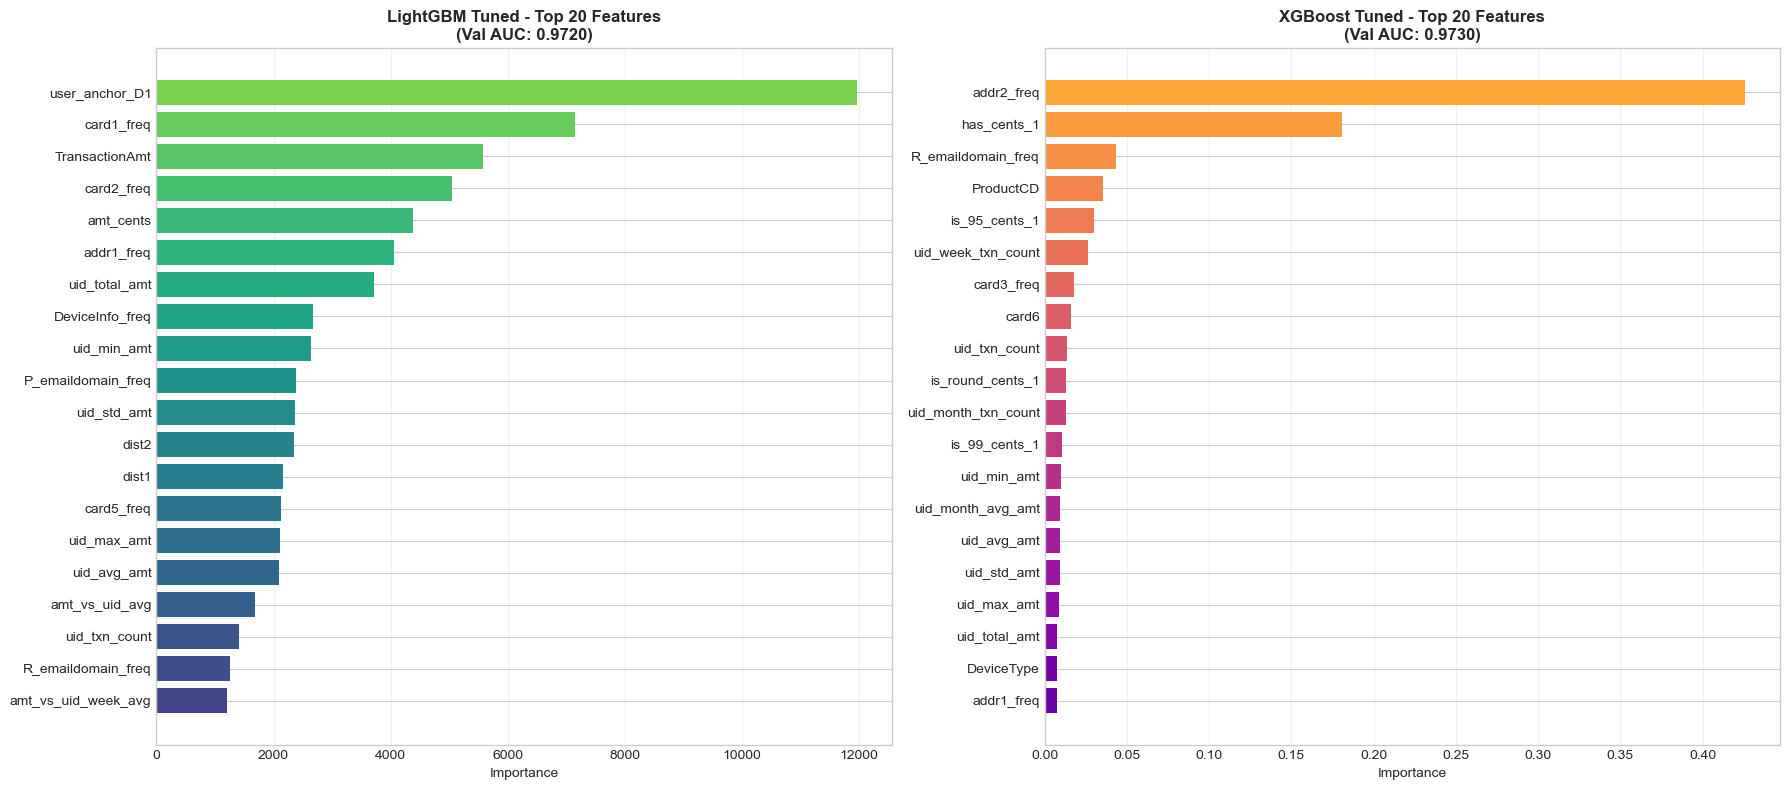

In [26]:
# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# LightGBM Feature Importance
lgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_tuned.feature_importances_
}).sort_values('importance', ascending=False).head(20)

ax1 = axes[0]
colors_lgb = plt.cm.viridis(np.linspace(0.8, 0.2, len(lgb_importance)))
ax1.barh(range(len(lgb_importance)), lgb_importance['importance'], color=colors_lgb)
ax1.set_yticks(range(len(lgb_importance)))
ax1.set_yticklabels(lgb_importance['feature'])
ax1.invert_yaxis()
ax1.set_xlabel('Importance')
ax1.set_title(f'LightGBM Tuned - Top 20 Features\n(Val AUC: {val_auc_lgb:.4f})', fontweight='bold')
ax1.grid(alpha=0.3, axis='x')

# XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_tuned.feature_importances_
}).sort_values('importance', ascending=False).head(20)

ax2 = axes[1]
colors_xgb = plt.cm.plasma(np.linspace(0.8, 0.2, len(xgb_importance)))
ax2.barh(range(len(xgb_importance)), xgb_importance['importance'], color=colors_xgb)
ax2.set_yticks(range(len(xgb_importance)))
ax2.set_yticklabels(xgb_importance['feature'])
ax2.invert_yaxis()
ax2.set_xlabel('Importance')
ax2.set_title(f'XGBoost Tuned - Top 20 Features\n(Val AUC: {val_auc_xgb:.4f})', fontweight='bold')
ax2.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

---
## 📊 Özet ve Sonraki Adımlar

### ✅ Yapılanlar:
1. ✅ Baseline performans değerleri yüklendi
2. ✅ LightGBM hyperparameter tuning (Optuna TPESampler)
3. ✅ XGBoost hyperparameter tuning (Optuna TPESampler)
4. ✅ Final modeller en iyi parametrelerle eğitildi
5. ✅ Baseline vs Tuned karşılaştırması yapıldı
6. ✅ Optuna görselleştirmeleri oluşturuldu
7. ✅ MLflow ile model tracking yapıldı
8. ✅ Tuned modeller ve metadata kaydedildi
9. ✅ Feature importance analizi yapıldı

### 📈 Sonuçlar:
- LightGBM ve XGBoost için en iyi hyperparametreler bulundu
- Baseline'a göre AUC improvement hesaplandı
- En iyi model belirlendi

### 📂 Kaydedilen Dosyalar:
- `../../models/fraud_detection/optimized/lightgbm_tuned.pkl`
- `../../models/fraud_detection/optimized/xgboost_tuned.pkl`
- `../../models/fraud_detection/optimized/optimization_metadata.json`
- `../../models/fraud_detection/optimized/optuna_study_lgb.pkl`
- `../../models/fraud_detection/optimized/optuna_study_xgb.pkl`

### 🔍 MLflow Tracking:
- Experiment: `fraud_detection_optimization`
- Models: LightGBM Tuned, XGBoost Tuned
- Metrics: AUC, Precision, Recall, F1-Score, Improvement

### 🚀 Sonraki Adımlar:
1. Threshold optimization (Precision-Recall tradeoff)
2. Ensemble modeller (Voting, Stacking)
3. Test verisi üzerinde final prediction
4. Submission dosyası oluşturma
5. Model deployment

### 💡 MLflow UI'yi Başlatma:
```bash
cd notebooks/modeling
mlflow ui
```
Tarayıcıda: http://localhost:5000